In [1]:
import sys
sys.path.insert(0, '../')

import matplotlib.pyplot as plt
import pyflubl
import test_T001_Drift
import uproot
import numpy
import awkward as ak

initializing ocelot...


In [2]:
m = test_T001_Drift.make_T001_drift()
d = pyflubl.Analysis.openFile("./T001_Drift001_dump","usrdump")

pyflubl.BuilderNew.Machine.Write: Writing model to file...
pyflubl.BuilderNew.Machine.MakeFlukaModel:
pyflubl.BuilderNew.Machine.ElementFactory: Making FLUKA geometry for  s1 sampler_plane
pyflubl.BuilderNew.Machine.MakeFlukaSampler: Making sampler element  s1
pyflubl.BuilderNew.Machine.ElementFactory: Making FLUKA geometry for  d1 drift
pyflubl.BuilderNew.Machine.MakeFlukaDrift: Making drfit element  d1
pyflubl.BuilderNew.Machine.ElementFactory: Making FLUKA geometry for  s2 sampler_plane
pyflubl.BuilderNew.Machine.MakeFlukaSampler: Making sampler element  s2
pyflubl.BuilderNew.Machine._MakeBookkeepingInfo: Making bookkeeping information...


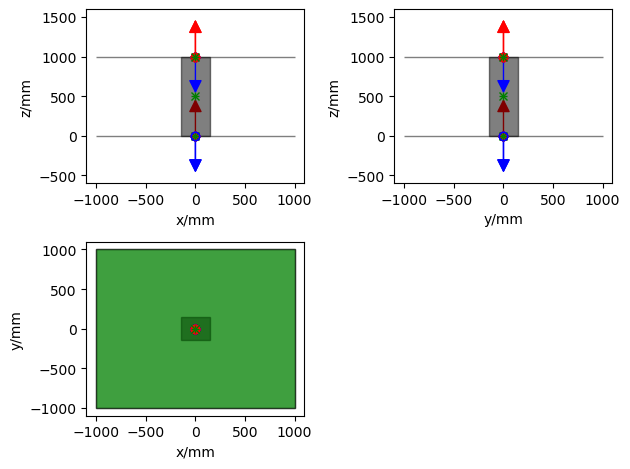

In [3]:
pyflubl.Analysis.plot_coordinates(m)

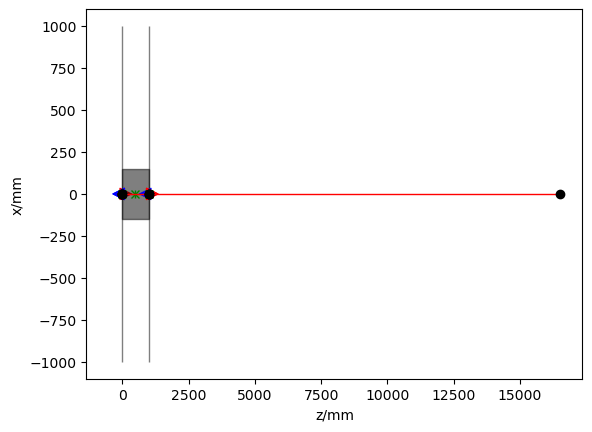

In [5]:
d.read_event(0)
pyflubl.Analysis.plot_coordinates_projection(m,"zx")
pyflubl.Analysis.plot_usrdump(d,"zx")

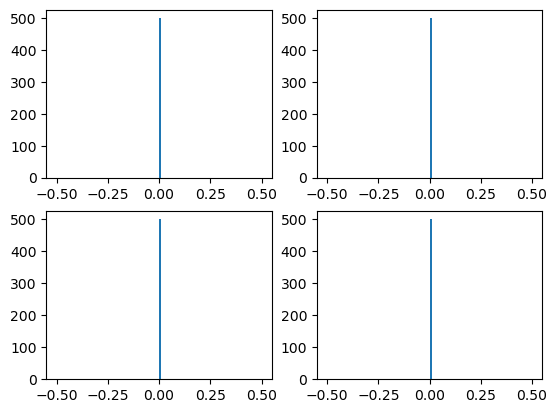

In [6]:
bk = pyflubl.Analysis.openBookkeepingFile("./pyflubl.json")
list(bk['samplernames_samplernumber'].keys())

trees = [uproot.open(f)["event"] for f in ["T001_Drift001_pyflubl.root"]]

arrays = [tree["s1.x"].array() for tree in trees]
s1_x_all = numpy.ravel(ak.concatenate(arrays))

arrays = [tree["s1.y"].array() for tree in trees]
s1_y_all = numpy.ravel(ak.concatenate(arrays))


arrays = [tree["s2.x"].array() for tree in trees]
s2_x_all = numpy.ravel(ak.concatenate(arrays))

arrays = [tree["s2.y"].array() for tree in trees]
s2_y_all = numpy.ravel(ak.concatenate(arrays))

plt.subplot(2,2,1)
plt.hist(s1_x_all,100);

plt.subplot(2,2,2)
plt.hist(s1_y_all,100);

plt.subplot(2,2,3)
plt.hist(s2_x_all,100);

plt.subplot(2,2,4)
plt.hist(s2_y_all,100);